# Signal Research Notebook

Interactive research and development notebook for signal creation and testing.

## Workflow
1. **Load & Explore Data** - Load market data and inspect distributions
2. **Develop Signal** - Build and test signal logic interactively
3. **Implement** - Copy validated logic to `create_signal.py`
4. **Execute** - Run `uv run create-signal` to generate `data/signal.parquet`
5. **Validate Signal** - use `uv run ew-dash` to view signal characteristics.
6. **Backtest** - Use `uv run backtest` for slurm backtest on super computer
7. **Performance** - Use `uv run opt-dash` for in depth analysis of mvo backtested signal.

## Tips
- Use cells to isolate different aspects of your signal
- Modify parameters directly in cells to test variations
- Check signal statistics regularly to catch issues early
- Document your assumptions and findings as you develop

## Setup

In [1]:
import polars as pl
import numpy as np
import datetime as dt
import sf_quant.data as sfd
import sf_quant.research as sfr
import polars_ols

## 1. Load & Explore Data

Load your market data and inspect key characteristics before developing the signal.

In [2]:
# Configurations

# industry_cols = ['date', 'barrid', 'USSLOWL_AERODEF']

industry_cols = [
        "date", "barrid",
        "USSLOWL_AERODEF", "USSLOWL_AIRLINES", "USSLOWL_ALUMSTEL", "USSLOWL_APPAREL",
        "USSLOWL_AUTO", "USSLOWL_BANKS", "USSLOWL_BEVTOB", "USSLOWL_BIOLIFE",
        "USSLOWL_BLDGPROD", "USSLOWL_CHEM", "USSLOWL_CNSTENG", "USSLOWL_CNSTMACH",
        "USSLOWL_CNSTMATL", "USSLOWL_COMMEQP", "USSLOWL_COMPELEC", "USSLOWL_COMSVCS",
        "USSLOWL_CONGLOM", "USSLOWL_CONTAINR", "USSLOWL_DISTRIB", "USSLOWL_DIVFIN",
        "USSLOWL_ELECEQP", "USSLOWL_ELECUTIL", "USSLOWL_FOODPROD", "USSLOWL_FOODRET",
        "USSLOWL_GASUTIL", "USSLOWL_HLTHEQP", "USSLOWL_HLTHSVCS", "USSLOWL_HOMEBLDG",
        "USSLOWL_HOUSEDUR", "USSLOWL_INDMACH", "USSLOWL_INSURNCE", "USSLOWL_INTERNET",
        "USSLOWL_LEISPROD", "USSLOWL_LEISSVCS", "USSLOWL_LIFEINS", "USSLOWL_MEDIA",
        "USSLOWL_MGDHLTH", "USSLOWL_MULTUTIL", "USSLOWL_OILGSCON", "USSLOWL_OILGSDRL",
        "USSLOWL_OILGSEQP", "USSLOWL_OILGSEXP", "USSLOWL_PAPER", "USSLOWL_PHARMA",
        "USSLOWL_PRECMTLS", "USSLOWL_PSNLPROD", "USSLOWL_REALEST", "USSLOWL_RESTAUR",
        "USSLOWL_ROADRAIL", "USSLOWL_SEMICOND", "USSLOWL_SEMIEQP", "USSLOWL_SOFTWARE",
        "USSLOWL_SPLTYRET", "USSLOWL_SPTYCHEM", "USSLOWL_SPTYSTOR", "USSLOWL_TELECOM",
        "USSLOWL_TRADECO", "USSLOWL_TRANSPRT", "USSLOWL_WIRELESS",
    ]

industry_only = [c for c in industry_cols if c not in ["date", "barrid"]]

start = dt.date(2012, 1, 1)
end = dt.date(2024, 12, 31)

asset_columns = ['barrid', 'date', 'predicted_beta', 'return', 'specific_risk', 'price']

In [3]:
# Create Industry_exposure_df
# 0 indicates that stock is NOT in the industry and 1 indicates the stock IS in the industry
industry_exposures_df = sfd.load_exposures(
    start=start, 
    end=end, 
    in_universe=True,
    columns=industry_cols
)

industry_only = [c for c in industry_cols if c not in ["date", "barrid"]]

industry_exposures_df = industry_exposures_df.with_columns(
    pl.when(pl.col(c).is_null()).then(pl.lit(0)).otherwise(pl.lit(1)).cast(pl.Int8).alias(c)
    for c in industry_only
)


industry_exposures_df

date,barrid,USSLOWL_AERODEF,USSLOWL_AIRLINES,USSLOWL_ALUMSTEL,USSLOWL_APPAREL,USSLOWL_AUTO,USSLOWL_BANKS,USSLOWL_BEVTOB,USSLOWL_BIOLIFE,USSLOWL_BLDGPROD,USSLOWL_CHEM,USSLOWL_CNSTENG,USSLOWL_CNSTMACH,USSLOWL_CNSTMATL,USSLOWL_COMMEQP,USSLOWL_COMPELEC,USSLOWL_COMSVCS,USSLOWL_CONGLOM,USSLOWL_CONTAINR,USSLOWL_DISTRIB,USSLOWL_DIVFIN,USSLOWL_ELECEQP,USSLOWL_ELECUTIL,USSLOWL_FOODPROD,USSLOWL_FOODRET,USSLOWL_GASUTIL,USSLOWL_HLTHEQP,USSLOWL_HLTHSVCS,USSLOWL_HOMEBLDG,USSLOWL_HOUSEDUR,USSLOWL_INDMACH,USSLOWL_INSURNCE,USSLOWL_INTERNET,USSLOWL_LEISPROD,USSLOWL_LEISSVCS,USSLOWL_LIFEINS,USSLOWL_MEDIA,USSLOWL_MGDHLTH,USSLOWL_MULTUTIL,USSLOWL_OILGSCON,USSLOWL_OILGSDRL,USSLOWL_OILGSEQP,USSLOWL_OILGSEXP,USSLOWL_PAPER,USSLOWL_PHARMA,USSLOWL_PRECMTLS,USSLOWL_PSNLPROD,USSLOWL_REALEST,USSLOWL_RESTAUR,USSLOWL_ROADRAIL,USSLOWL_SEMICOND,USSLOWL_SEMIEQP,USSLOWL_SOFTWARE,USSLOWL_SPLTYRET,USSLOWL_SPTYCHEM,USSLOWL_SPTYSTOR,USSLOWL_TELECOM,USSLOWL_TRADECO,USSLOWL_TRANSPRT,USSLOWL_WIRELESS
date,str,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8
2013-07-31,"""USA06Z1""",0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2013-08-01,"""USA06Z1""",0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2013-08-02,"""USA06Z1""",0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2013-08-05,"""USA06Z1""",0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2013-08-06,"""USA06Z1""",0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2024-12-24,"""USBQOR1""",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2024-12-26,"""USBQOR1""",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2024-12-27,"""USBQOR1""",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [4]:
# create the assets data frame

assets_df = sfd.load_assets(
    start=start,
    end=end,
    columns=asset_columns,
    in_universe=True,
)

assets_df

barrid,date,predicted_beta,return,specific_risk,price
str,date,f64,f64,f64,f64
"""USA06Z1""",2013-07-31,0.34349,-0.1595,55.056916,6.26
"""USA06Z1""",2013-08-01,0.353329,0.9585,55.028021,6.32
"""USA06Z1""",2013-08-02,0.363624,-0.1582,54.807402,6.31
"""USA06Z1""",2013-08-05,0.356596,2.2187,54.76671,6.45
"""USA06Z1""",2013-08-06,0.399196,-2.4806,54.692162,6.29
…,…,…,…,…,…
"""USBQOR1""",2024-12-24,1.287294,2.5872,26.800417,70.58
"""USBQOR1""",2024-12-26,1.288943,4.293,27.172284,73.61
"""USBQOR1""",2024-12-27,1.294801,-5.108,27.468053,69.85


In [5]:
# # Perform left merge on assets data frame with indsutry exposure data frame

# df = assets_df.join(
#     industry_exposures_df, on=['date', 'barrid'], how='left'
#     )

# # calculate log returns and shift them

# df = (df
#       .with_columns(
#           pl.col('return')
#           .truediv(100)
#       )
#       .with_columns(
#           pl.col('return')
#           .log1p()
#           .alias('logreturn')
#       )
#       .sort(['date', 'barrid'])
# )
# df

industry_map = (
        industry_exposures_df                          # wide: barrid, date, 59 industry cols
        .unpivot(
            on=industry_only,
            index=["barrid", "date"],                 # only carry the keys through the explosion
            variable_name="industry",
            value_name="val",
        )
        .filter(pl.col("val") == 1)                   # keep only the industry each stock belongs to
        .drop("val")                                   # no longer needed
    )

industry_map

barrid,date,industry
str,date,str
"""USA16A1""",2014-07-31,"""USSLOWL_AERODEF"""
"""USA16A1""",2014-08-01,"""USSLOWL_AERODEF"""
"""USA16A1""",2014-08-04,"""USSLOWL_AERODEF"""
"""USA16A1""",2014-08-05,"""USSLOWL_AERODEF"""
"""USA16A1""",2014-08-06,"""USSLOWL_AERODEF"""
…,…,…
"""USBNF21""",2022-10-19,"""USSLOWL_WIRELESS"""
"""USBNF21""",2022-10-20,"""USSLOWL_WIRELESS"""
"""USBNF21""",2022-10-21,"""USSLOWL_WIRELESS"""


In [6]:
# long = (
#     df
#     .unpivot(
#         on=industry_only,          # columns to melt
#         index=["barrid", "date", "return", "predicted_beta", "specific_risk", "price"],  # columns to keep as-is
#         variable_name="industry",
#         value_name="val",
#     )
#     .filter(pl.col("val") == 1)    # keep only rows where stock IS in that industry
#     .drop("val")
#     .sort(['date', 'industry'])
# )

# long

long = (
        industry_map
        .join(assets_df, on=["barrid", "date"], how="left")
        .with_columns(pl.col("return").truediv(100))
        .with_columns(pl.col("return").log1p().alias("logreturn"))
        .sort(["date", "industry"])
    )

long

barrid,date,industry,predicted_beta,return,specific_risk,price,logreturn
str,date,str,f64,f64,f64,f64,f64
"""USAG4G1""",2012-01-03,"""USSLOWL_AERODEF""",0.412147,-0.002102,21.07325,123.44,-0.002104
"""USAFB21""",2012-01-03,"""USSLOWL_AERODEF""",1.135251,0.028729,23.598595,9.31,0.028324
"""USADQH1""",2012-01-03,"""USSLOWL_AERODEF""",1.247222,0.014435,17.226414,35.84,0.014332
"""USA38X1""",2012-01-03,"""USSLOWL_AERODEF""",1.217499,0.017685,18.367884,55.82,0.01753
"""USAJOD1""",2012-01-03,"""USSLOWL_AERODEF""",1.060434,0.012393,18.964308,94.76,0.012317
…,…,…,…,…,…,…,…
"""USBBIE1""",2024-12-31,"""USSLOWL_WIRELESS""",1.861435,-0.009506,93.068204,5.21,-0.009551
"""USABND1""",2024-12-31,"""USSLOWL_WIRELESS""",0.131135,0.009848,14.114832,39.99,0.0098
"""USANIP1""",2024-12-31,"""USSLOWL_WIRELESS""",0.858926,0.00294,47.092951,34.11,0.002936


In [7]:
# Create Equal Weight Portfolio

ew_port = (
    long
    .group_by(["date", "industry"])
    .agg(
        pl.col('return').mean().alias("ew_return"),
        )
    .sort(["industry", "date"])
)

ew_port

date,industry,ew_return
date,str,f64
2012-01-03,"""USSLOWL_AERODEF""",0.015474
2012-01-04,"""USSLOWL_AERODEF""",-0.00613
2012-01-05,"""USSLOWL_AERODEF""",0.003515
2012-01-06,"""USSLOWL_AERODEF""",0.001465
2012-01-09,"""USSLOWL_AERODEF""",0.004651
…,…,…
2024-12-24,"""USSLOWL_WIRELESS""",0.01456
2024-12-26,"""USSLOWL_WIRELESS""",0.011031
2024-12-27,"""USSLOWL_WIRELESS""",-0.010574


In [ ]:
# Calculate Momentum

industry_momentum = (
    ew_port
    .sort(['date', 'industry'])
    .with_columns(
        pl.col('ew_return')
        .rolling_sum(window_size=230)
        .over('industry')
        .alias('momentum')
    )
    .with_columns(
        pl.col('momentum')
        .shift(22)
        .over('industry')
    )
)
industry_momentum

date,industry,ew_return,momentum
date,str,f64,f64
2012-01-03,"""USSLOWL_AERODEF""",0.015474,null
2012-01-03,"""USSLOWL_AIRLINES""",-0.004664,null
2012-01-03,"""USSLOWL_ALUMSTEL""",0.045896,null
2012-01-03,"""USSLOWL_APPAREL""",-0.004887,null
2012-01-03,"""USSLOWL_AUTO""",0.031185,null
…,…,…,…
2024-12-31,"""USSLOWL_SPTYSTOR""",0.008668,0.137283
2024-12-31,"""USSLOWL_TELECOM""",0.0022563,0.478099
2024-12-31,"""USSLOWL_TRADECO""",0.006574,0.252556


In [ ]:
# go back to stock space and filter price

long = (long
        .join(industry_momentum, on=['date', 'industry'], how='left')
        .filter(pl.col('price') >= 5)
        )
long

barrid,date,return,predicted_beta,specific_risk,price,industry,ew_return,momentum
str,date,f64,f64,f64,f64,str,f64,f64
"""USAZQO1""",2012-01-03,-0.003989,1.313776,35.567235,17.48,"""USSLOWL_AERODEF""",0.015474,null
"""USA1FI1""",2012-01-03,-0.035272,1.110591,35.711253,30.36,"""USSLOWL_AERODEF""",0.015474,null
"""USA4HN1""",2012-01-03,0.014087,0.945401,13.408377,56.15,"""USSLOWL_AERODEF""",0.015474,null
"""USA8BW1""",2012-01-03,0.024302,1.5507,47.755009,22.76,"""USSLOWL_AERODEF""",0.015474,null
"""USA38X1""",2012-01-03,0.017685,1.217499,18.367884,55.82,"""USSLOWL_AERODEF""",0.015474,null
…,…,…,…,…,…,…,…,…
"""USAPF22""",2024-12-31,0.003125,0.468975,34.023973,16.05,"""USSLOWL_WIRELESS""",0.009142,0.542521
"""USAUKV2""",2024-12-31,0.006149,1.178081,23.800082,47.45,"""USSLOWL_WIRELESS""",0.009142,0.542521
"""USBBAB1""",2024-12-31,0.065876,1.430728,40.679865,8.09,"""USSLOWL_WIRELESS""",0.009142,0.542521


In [ ]:
# z-score momentum

industry_momentum = long.with_columns(
    ((pl.col("momentum") - pl.col("momentum").mean().over("date")) / 
      pl.col("momentum").std().over("date"))
    .alias("score")
)

industry_momentum


barrid,date,return,predicted_beta,specific_risk,price,industry,ew_return,momentum,score
str,date,f64,f64,f64,f64,str,f64,f64,f64
"""USAZQO1""",2012-01-03,-0.003989,1.313776,35.567235,17.48,"""USSLOWL_AERODEF""",0.015474,null,null
"""USA1FI1""",2012-01-03,-0.035272,1.110591,35.711253,30.36,"""USSLOWL_AERODEF""",0.015474,null,null
"""USA4HN1""",2012-01-03,0.014087,0.945401,13.408377,56.15,"""USSLOWL_AERODEF""",0.015474,null,null
"""USA8BW1""",2012-01-03,0.024302,1.5507,47.755009,22.76,"""USSLOWL_AERODEF""",0.015474,null,null
"""USA38X1""",2012-01-03,0.017685,1.217499,18.367884,55.82,"""USSLOWL_AERODEF""",0.015474,null,null
…,…,…,…,…,…,…,…,…,…
"""USAPF22""",2024-12-31,0.003125,0.468975,34.023973,16.05,"""USSLOWL_WIRELESS""",0.009142,0.542521,3.395651
"""USAUKV2""",2024-12-31,0.006149,1.178081,23.800082,47.45,"""USSLOWL_WIRELESS""",0.009142,0.542521,3.395651
"""USBBAB1""",2024-12-31,0.065876,1.430728,40.679865,8.09,"""USSLOWL_WIRELESS""",0.009142,0.542521,3.395651


In [ ]:
# compute alpha

industry_momentum = (
    industry_momentum
    .with_columns(
        pl.col('specific_risk')
        .truediv(100)
    )
    .with_columns(
        pl.col('score')
        .mul(.05)
        .mul(pl.col('specific_risk'))
        .alias('alpha')
    )
)

industry_momentum

barrid,date,return,predicted_beta,specific_risk,price,industry,ew_return,momentum,score,alpha
str,date,f64,f64,f64,f64,str,f64,f64,f64,f64
"""USAZQO1""",2012-01-03,-0.003989,1.313776,0.355672,17.48,"""USSLOWL_AERODEF""",0.015474,null,null,null
"""USA1FI1""",2012-01-03,-0.035272,1.110591,0.357113,30.36,"""USSLOWL_AERODEF""",0.015474,null,null,null
"""USA4HN1""",2012-01-03,0.014087,0.945401,0.134084,56.15,"""USSLOWL_AERODEF""",0.015474,null,null,null
"""USA8BW1""",2012-01-03,0.024302,1.5507,0.47755,22.76,"""USSLOWL_AERODEF""",0.015474,null,null,null
"""USA38X1""",2012-01-03,0.017685,1.217499,0.183679,55.82,"""USSLOWL_AERODEF""",0.015474,null,null,null
…,…,…,…,…,…,…,…,…,…,…
"""USAPF22""",2024-12-31,0.003125,0.468975,0.34024,16.05,"""USSLOWL_WIRELESS""",0.009142,0.542521,3.395651,0.057767
"""USAUKV2""",2024-12-31,0.006149,1.178081,0.238001,47.45,"""USSLOWL_WIRELESS""",0.009142,0.542521,3.395651,0.040408
"""USBBAB1""",2024-12-31,0.065876,1.430728,0.406799,8.09,"""USSLOWL_WIRELESS""",0.009142,0.542521,3.395651,0.069067


In [ ]:
def load_data() -> pl.DataFrame:
    industry_cols = [
        "date", "barrid",
        "USSLOWL_AERODEF", "USSLOWL_AIRLINES", "USSLOWL_ALUMSTEL", "USSLOWL_APPAREL",
        "USSLOWL_AUTO", "USSLOWL_BANKS", "USSLOWL_BEVTOB", "USSLOWL_BIOLIFE",
        "USSLOWL_BLDGPROD", "USSLOWL_CHEM", "USSLOWL_CNSTENG", "USSLOWL_CNSTMACH",
        "USSLOWL_CNSTMATL", "USSLOWL_COMMEQP", "USSLOWL_COMPELEC", "USSLOWL_COMSVCS",
        "USSLOWL_CONGLOM", "USSLOWL_CONTAINR", "USSLOWL_DISTRIB", "USSLOWL_DIVFIN",
        "USSLOWL_ELECEQP", "USSLOWL_ELECUTIL", "USSLOWL_FOODPROD", "USSLOWL_FOODRET",
        "USSLOWL_GASUTIL", "USSLOWL_HLTHEQP", "USSLOWL_HLTHSVCS", "USSLOWL_HOMEBLDG",
        "USSLOWL_HOUSEDUR", "USSLOWL_INDMACH", "USSLOWL_INSURNCE", "USSLOWL_INTERNET",
        "USSLOWL_LEISPROD", "USSLOWL_LEISSVCS", "USSLOWL_LIFEINS", "USSLOWL_MEDIA",
        "USSLOWL_MGDHLTH", "USSLOWL_MULTUTIL", "USSLOWL_OILGSCON", "USSLOWL_OILGSDRL",
        "USSLOWL_OILGSEQP", "USSLOWL_OILGSEXP", "USSLOWL_PAPER", "USSLOWL_PHARMA",
        "USSLOWL_PRECMTLS", "USSLOWL_PSNLPROD", "USSLOWL_REALEST", "USSLOWL_RESTAUR",
        "USSLOWL_ROADRAIL", "USSLOWL_SEMICOND", "USSLOWL_SEMIEQP", "USSLOWL_SOFTWARE",
        "USSLOWL_SPLTYRET", "USSLOWL_SPTYCHEM", "USSLOWL_SPTYSTOR", "USSLOWL_TELECOM",
        "USSLOWL_TRADECO", "USSLOWL_TRANSPRT", "USSLOWL_WIRELESS",
    ]
    industry_only = [c for c in industry_cols if c not in ["date", "barrid"]]

    start = dt.date(2012, 1, 1)
    end = dt.date(2024, 12, 31)

    asset_columns = ['barrid', 'date', 'predicted_beta', 'return', 'specific_risk', 'price']

    # Create Industry_exposure_df
    # 0 indicates that stock is NOT in the industry and 1 indicates the stock IS in the industry
    
    industry_exposures_df = sfd.load_exposures(
        start=start, 
        end=end, 
        in_universe=True,
        columns=industry_cols
    )

    industry_only = [c for c in industry_cols if c not in ["date", "barrid"]]

    industry_exposures_df = industry_exposures_df.with_columns(
        pl.when(pl.col(c).is_null()).then(pl.lit(0)).otherwise(pl.lit(1)).cast(pl.Int8).alias(c)
        for c in industry_only
    )

    # create the assets data frame

    assets_df = sfd.load_assets(
        start=start,
        end=end,
        columns=asset_columns,
        in_universe=True,
    )

    # Perform left merge on assets data frame with indsutry exposure data frame

    df = assets_df.join(
        industry_exposures_df, on=['date', 'barrid'], how='left'
        )

    # calculate log returns and shift them

    df = (df
        .with_columns(
            pl.col('return')
            .truediv(100)
        )
        .with_columns(
            pl.col('return')
            .log1p()
            .alias('logreturn')
        )
        .sort(['date', 'barrid'])
    )

    long = (
    df
    .unpivot(
        on=industry_only,          # columns to melt
        index=["barrid", "date", "return", "predicted_beta", "specific_risk", "price"],  # columns to keep as-is
        variable_name="industry",
        value_name="val",
    )
    .filter(pl.col("val") == 1)    # keep only rows where stock IS in that industry
    .drop("val")
    .sort(['date', 'industry'])
    )

    # Create Equal Weight Portfolio

    ew_port = (
        long
        .group_by(["date", "industry"])
        .agg(
            pl.col('return').mean().alias("ew_return"),
            )
        .sort(["industry", "date"])
    )

    return ew_port, long
        

## 2. Signal Development

Build and test your signal logic. Modify parameters and logic here to find optimal configurations.

In [ ]:
def create_signal(df1: pl.DataFrame, df2: pl.DataFrame) -> pl.DataFrame:

    ew_port = df1
    long = df2
    
    # Calculate Momentum
    

    industry_momentum = (
        ew_port
        .sort(['date', 'industry'])
        .with_columns(
            pl.col('ew_return')
            .rolling_sum(window_size=230)
            .over('industry')
            .alias('momentum')
        )
        .with_columns(
            pl.col('momentum')
            .shift(22)
            .over('industry')
        )
    )
    # go back to stock space and filter price

    long = (long
            .join(industry_momentum, on=['date', 'industry'], how='left')
            .filter(pl.col('price') >= 5)
            )
    
    # z-score momentum

    industry_momentum = long.with_columns(
        ((pl.col("momentum") - pl.col("momentum").mean().over("date")) / 
        pl.col("momentum").std().over("date"))
        .alias("score")
    )
    # compute alpha

    industry_momentum = (
        industry_momentum
        .with_columns(
            pl.col('score')
            .mul(.05)
            .mul(pl.col('specific_risk'))
            .alias('alpha')
        )
        .with_columns(
            pl.col('alpha')
            .fill_null(0)
            .alias('alpha')
        )
    )

    return industry_momentum

    
industry_momentum = create_signal(ew_port, long)
industry_momentum
    


barrid,date,return,predicted_beta,specific_risk,price,industry,ew_return,momentum,ew_return_right,momentum_right,score,alpha
str,date,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64
"""USAZQO1""",2012-01-03,-0.003989,1.313776,35.567235,17.48,"""USSLOWL_AERODEF""",0.015474,null,0.015474,null,null,0.0
"""USA1FI1""",2012-01-03,-0.035272,1.110591,35.711253,30.36,"""USSLOWL_AERODEF""",0.015474,null,0.015474,null,null,0.0
"""USA4HN1""",2012-01-03,0.014087,0.945401,13.408377,56.15,"""USSLOWL_AERODEF""",0.015474,null,0.015474,null,null,0.0
"""USA8BW1""",2012-01-03,0.024302,1.5507,47.755009,22.76,"""USSLOWL_AERODEF""",0.015474,null,0.015474,null,null,0.0
"""USA38X1""",2012-01-03,0.017685,1.217499,18.367884,55.82,"""USSLOWL_AERODEF""",0.015474,null,0.015474,null,null,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…
"""USAPF22""",2024-12-31,0.003125,0.468975,34.023973,16.05,"""USSLOWL_WIRELESS""",0.009142,0.542521,0.009142,0.542521,3.395651,5.776678
"""USAUKV2""",2024-12-31,0.006149,1.178081,23.800082,47.45,"""USSLOWL_WIRELESS""",0.009142,0.542521,0.009142,0.542521,3.395651,4.040839
"""USBBAB1""",2024-12-31,0.065876,1.430728,40.679865,8.09,"""USSLOWL_WIRELESS""",0.009142,0.542521,0.009142,0.542521,3.395651,6.906732


## 3. Signal Analysis

Examine signal statistics and distributions to understand its characteristics.

### Statistics

In [ ]:
# sfr.get_signal_stats(signal)
sfr.get_signal_stats(industry_momentum, column='momentum')

mean,std,min,max,q25,q50,q75
f64,f64,f64,f64,f64,f64,f64
0.119117,0.218783,-1.689089,1.726996,-0.002211,0.118052,0.231836


### Distribution

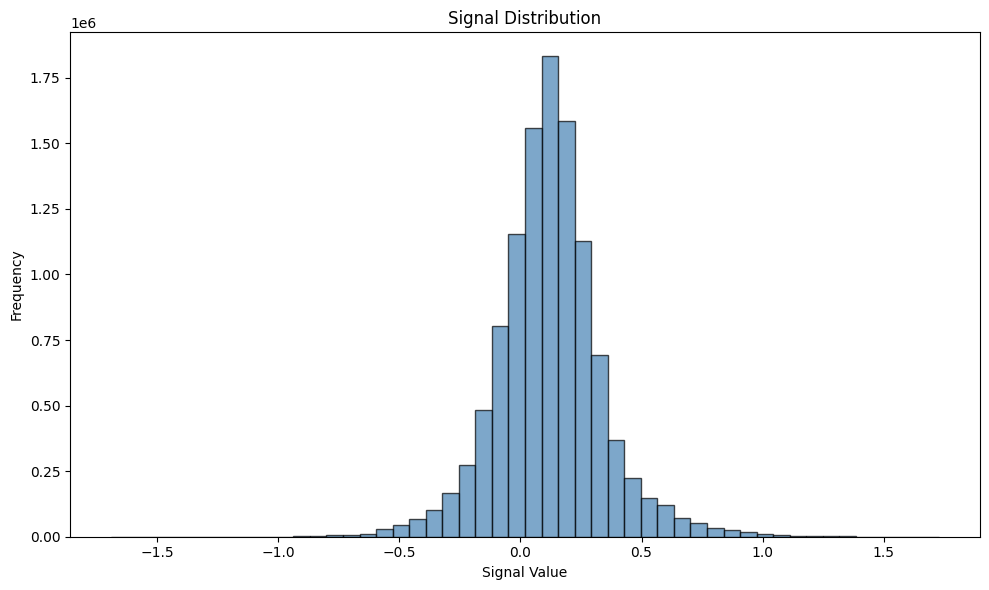

In [ ]:
# sfr.get_signal_distribution(signal)
sfr.get_signal_distribution(industry_momentum, column='momentum')

## 4. Validation Checks ?

Verify signal quality and identify any issues before implementation.

## 5. Next Steps

When satisfied with your signal:

1. **Copy** your data loading and signal calculation logic to `create_signal.py`
2. **Run** `uv run create-signal` to save the signal to `data/signal.parquet`
3. **Open** `uv run ew-dash` to analyze the signal before backtesting